# Proyek Akhir: Menyelesaikan Permasalahan Perusahaan Jaya Jaya Maju

- Nama: Fathan Askar
- Email: askarfathan@gmail.com
- Id Dicoding: askarfathan

## Persiapan

### Menyiapkan library yang dibutuhkan

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier
import joblib

### Menyiapkan data yang akan diguankan

In [2]:
df = pd.read_csv("employee_data.csv")

## Data Understanding

In [3]:
print(f"Jumlah baris dan kolom: {df.shape}")
print("\nNama-nama kolom:")
print(df.columns.tolist())

Jumlah baris dan kolom: (1470, 35)

Nama-nama kolom:
['EmployeeId', 'Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


In [4]:
print("\nStatistik deskriptif:")
print(df.describe())


Statistik deskriptif:
        EmployeeId          Age    Attrition    DailyRate  DistanceFromHome  \
count  1470.000000  1470.000000  1058.000000  1470.000000       1470.000000   
mean    735.500000    36.923810     0.169187   802.485714          9.192517   
std     424.496761     9.135373     0.375094   403.509100          8.106864   
min       1.000000    18.000000     0.000000   102.000000          1.000000   
25%     368.250000    30.000000     0.000000   465.000000          2.000000   
50%     735.500000    36.000000     0.000000   802.000000          7.000000   
75%    1102.750000    43.000000     0.000000  1157.000000         14.000000   
max    1470.000000    60.000000     1.000000  1499.000000         29.000000   

         Education  EmployeeCount  EnvironmentSatisfaction   HourlyRate  \
count  1470.000000         1470.0              1470.000000  1470.000000   
mean      2.912925            1.0                 2.721769    65.891156   
std       1.024165            0.0       

In [5]:
print("\nTipe data setiap kolom:")
print(df.dtypes)


Tipe data setiap kolom:
EmployeeId                    int64
Age                           int64
Attrition                   float64
BusinessTravel               object
DailyRate                     int64
Department                   object
DistanceFromHome              int64
Education                     int64
EducationField               object
EmployeeCount                 int64
EnvironmentSatisfaction       int64
Gender                       object
HourlyRate                    int64
JobInvolvement                int64
JobLevel                      int64
JobRole                      object
JobSatisfaction               int64
MaritalStatus                object
MonthlyIncome                 int64
MonthlyRate                   int64
NumCompaniesWorked            int64
Over18                       object
OverTime                     object
PercentSalaryHike             int64
PerformanceRating             int64
RelationshipSatisfaction      int64
StandardHours                 int64
Sto

In [6]:
print("\nJumlah missing values tiap kolom:")
print(df.isnull().sum().sort_values(ascending=False))


Jumlah missing values tiap kolom:
Attrition                   412
EmployeeId                    0
StandardHours                 0
NumCompaniesWorked            0
Over18                        0
OverTime                      0
PercentSalaryHike             0
PerformanceRating             0
RelationshipSatisfaction      0
StockOptionLevel              0
MonthlyIncome                 0
TotalWorkingYears             0
TrainingTimesLastYear         0
WorkLifeBalance               0
YearsAtCompany                0
YearsInCurrentRole            0
YearsSinceLastPromotion       0
MonthlyRate                   0
MaritalStatus                 0
Age                           0
JobSatisfaction               0
JobRole                       0
JobLevel                      0
JobInvolvement                0
HourlyRate                    0
Gender                        0
EnvironmentSatisfaction       0
EmployeeCount                 0
EducationField                0
Education                     0
Dista

In [7]:
#Check duplicate rows
duplicate_rows = df.duplicated().sum()
print(f"Jumlah baris duplikat: {duplicate_rows}")

Jumlah baris duplikat: 0


In [8]:
print("\nDistribusi nilai kolom 'Attrition':")
print(df['Attrition'].value_counts(dropna=False))


Distribusi nilai kolom 'Attrition':
Attrition
0.0    879
NaN    412
1.0    179
Name: count, dtype: int64


In [9]:
#Calculate attrition rate
total_employees = df.shape[0]
employees_left = df['Attrition'].sum()

attrition_rate = (employees_left / total_employees) * 100

print(f"Attrition Rate: {attrition_rate:.2f}%")

Attrition Rate: 12.18%


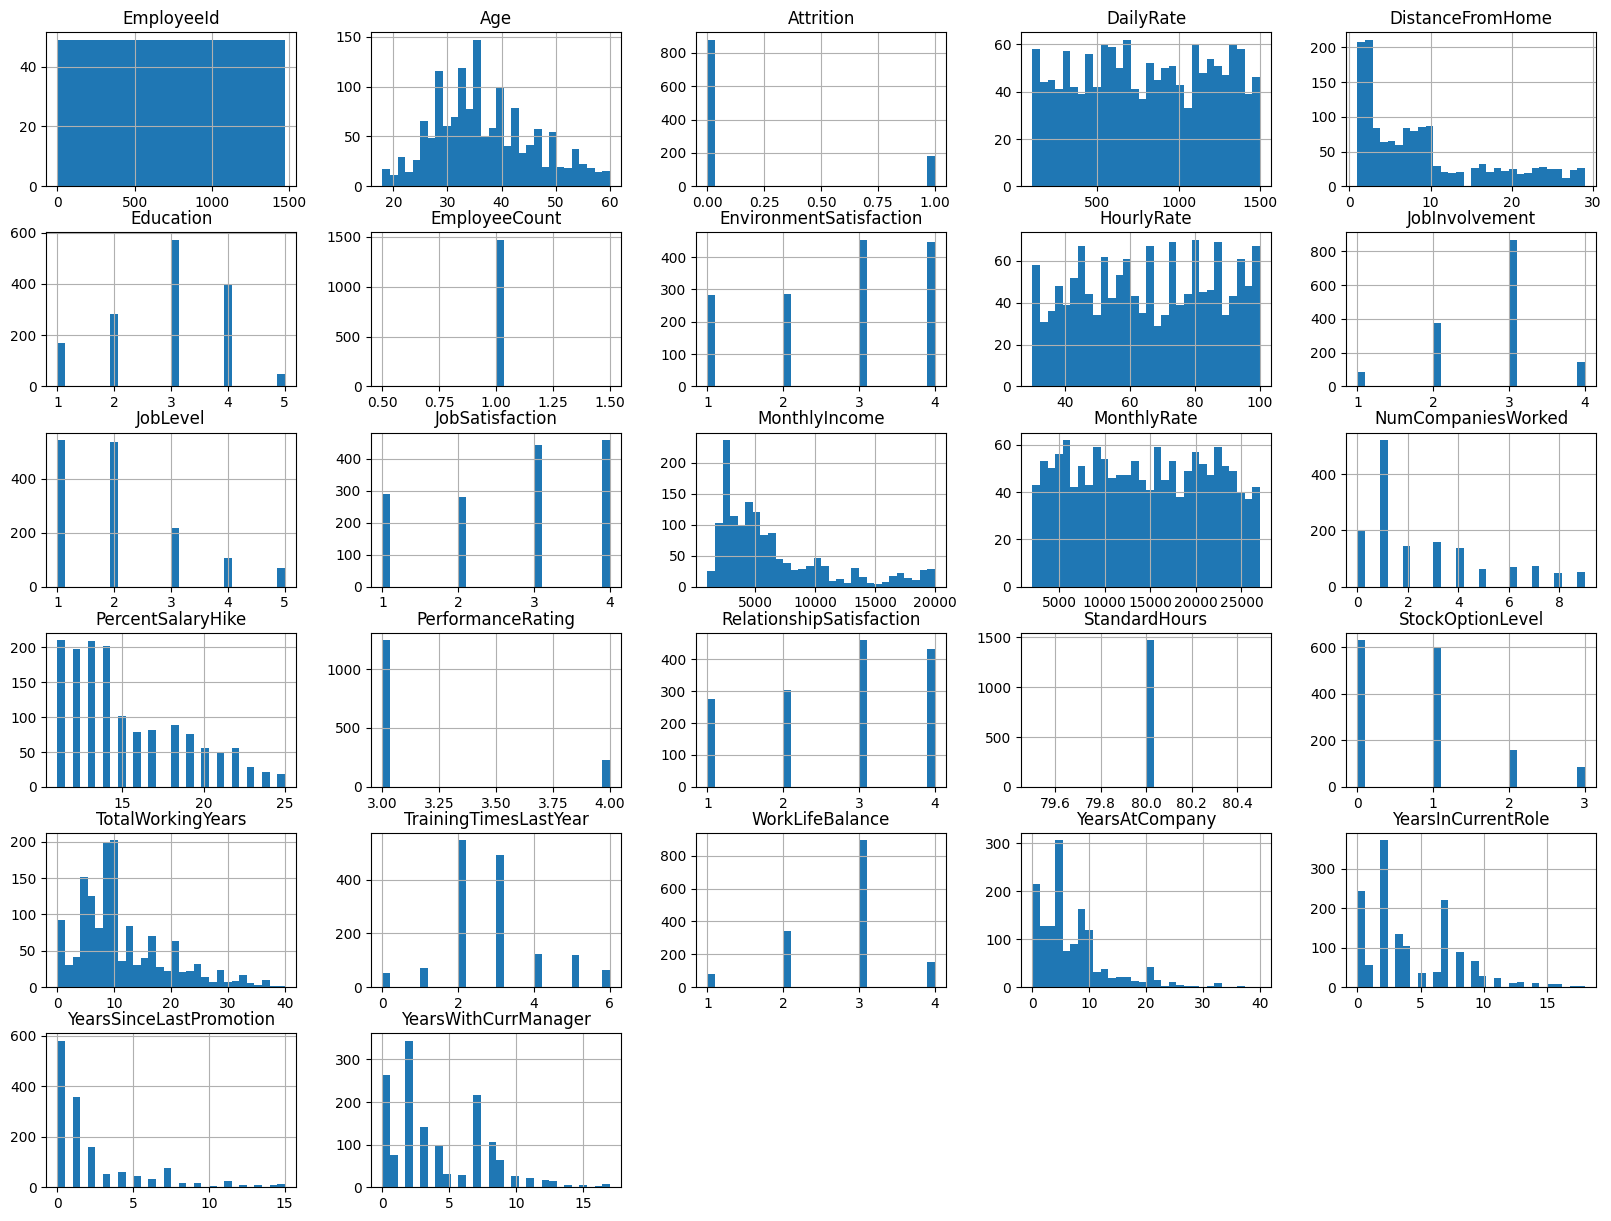

In [10]:
#histograms

df.hist(bins=30, figsize=(20,15))
plt.show()

In [11]:
for col in ['Department', 'BusinessTravel', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']:
    print(f"\nUnique values in {col}:")
    print(df[col].value_counts())


Unique values in Department:
Department
Research & Development    961
Sales                     446
Human Resources            63
Name: count, dtype: int64

Unique values in BusinessTravel:
BusinessTravel
Travel_Rarely        1043
Travel_Frequently     277
Non-Travel            150
Name: count, dtype: int64

Unique values in EducationField:
EducationField
Life Sciences       606
Medical             464
Marketing           159
Technical Degree    132
Other                82
Human Resources      27
Name: count, dtype: int64

Unique values in Gender:
Gender
Male      882
Female    588
Name: count, dtype: int64

Unique values in JobRole:
JobRole
Sales Executive              326
Research Scientist           292
Laboratory Technician        259
Manufacturing Director       145
Healthcare Representative    131
Manager                      102
Sales Representative          83
Research Director             80
Human Resources               52
Name: count, dtype: int64

Unique values in MaritalS

In [12]:
# df['EmployeeCount'].unique()  #1
# df['StandardHours'].unique()  #80
# df['Over18'].unique()  #'Y'

##### Observasi:

- Kolom `Attrition` memiliki distribusi tidak seimbang (sekitar 12% karyawan keluar).
- Sebanyak 412 baris tidak memiliki nilai `Attrition`, kemungkinan dapat digunakan untuk prediksi di tahap modeling. Tetapi untuk tahap Analisis perlu dihapus.
- Terdapat kolom dengan nilai tetap (konstan) seperti `EmployeeCount`, `StandardHours`, dan `Over18` — tidak informatif dan bisa dihapus.
- Kolom kategorikal yang perlu diencoding untuk analisis atau modeling antara lain: `Department`, `BusinessTravel`, `Gender`, `JobRole`, `MaritalStatus`, `OverTime`, dll.
- Kolom ordinal (dengan skala 1–4 atau 1–5) seperti `JobSatisfaction`, `WorkLifeBalance`, dan `EnvironmentSatisfaction` penting untuk dianalisis lebih lanjut terhadap attrition.


## Data Preparation / Preprocessing

##### Penanganan Missing Values:

Kolom `Attrition` memiliki 412 nilai kosong. Karena kolom ini merupakan label target utama, maka baris-baris tersebut dihapus dari dataset utama. Data yang digunakan untuk analisis dan modeling hanya mencakup baris yang memiliki label `Attrition` (0 = tidak keluar, 1 = keluar).

In [13]:
#Delete rows with missing attrition values
df_clean = df[df['Attrition'].notna()].copy()
df_clean['Attrition'] = df_clean['Attrition'].astype(int)
df_clean = df_clean.dropna()

print("Jumlah baris setelah menghapus NaN:", df_clean.shape)
print("Distribusi attrition:")
print(df_clean['Attrition'].value_counts())

Jumlah baris setelah menghapus NaN: (1058, 35)
Distribusi attrition:
Attrition
0    879
1    179
Name: count, dtype: int64


#### Attrition Rate

Dari total 1.058 karyawan dengan label `Attrition`:
- Jumlah karyawan yang keluar: 179
- Sehingga, attrition rate = (179 / 1058) × 100% ≈ 16.91%

Ini menunjukkan bahwa tingkat turnover di perusahaan cukup tinggi dan menjadi perhatian serius bagi departemen HR.

In [14]:
#Calculate clean attrition rate
total_employees = df_clean.shape[0]
employees_left = df_clean['Attrition'].sum()

attrition_rate = (employees_left / total_employees) * 100

print(f"Attrition Rate: {attrition_rate:.2f}%")

Attrition Rate: 16.92%


##### Penanganan Constant Values:
Kolom `EmployeeCount`, `StandardHours`, dan `Over18` memiliki nilai yang samaa untuk setiap baris. Agar analisis dan pemodelan lebih efektif, kolom-kolom ini dapat dihapus karena tidak memberikan informasi yang berguna.

In [15]:
#Remove constant columns
columns_to_drop = ['EmployeeCount', 'StandardHours', 'Over18']
df_clean = df.drop(columns=columns_to_drop)

In [16]:
#Encode categorical columns
categorical_cols = ['BusinessTravel', 'Department', 'EducationField', 
                    'Gender', 'JobRole', 'MaritalStatus', 'OverTime']

df_clean_encoded = pd.get_dummies(df_clean, columns=categorical_cols, drop_first=True)
df_clean_encoded.head()

,EmployeeId,Age,Attrition,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,1,38,NaN,1444,1,4,4,88,3,1,...,False,False,False,False,False,False,False,True,False,True
1,2,37,1.0,1141,11,2,1,61,1,2,...,False,False,False,False,False,False,False,True,False,False
2,3,51,1.0,1323,4,4,1,34,3,1,...,False,False,False,False,True,False,False,True,False,True
3,4,42,0.0,555,26,3,3,77,3,4,...,False,False,False,False,False,True,False,True,False,False
4,5,40,NaN,1194,2,4,3,98,3,1,...,False,False,False,False,True,False,False,True,False,False


In [17]:
df_clean_encoded.columns

Index(['EmployeeId', 'Age', 'Attrition', 'DailyRate', 'DistanceFromHome',
       'Education', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement',
       'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate',
       'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears',
       'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany',
       'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager',
       'BusinessTravel_Travel_Frequently', 'BusinessTravel_Travel_Rarely',
       'Department_Research & Development', 'Department_Sales',
       'EducationField_Life Sciences', 'EducationField_Marketing',
       'EducationField_Medical', 'EducationField_Other',
       'EducationField_Technical Degree', 'Gender_Male',
       'JobRole_Human Resources', 'JobRole_Laboratory Technician',
       'JobRole_Manager', 'JobRole_Manufacturing Director',
       'JobRole_Research Director'

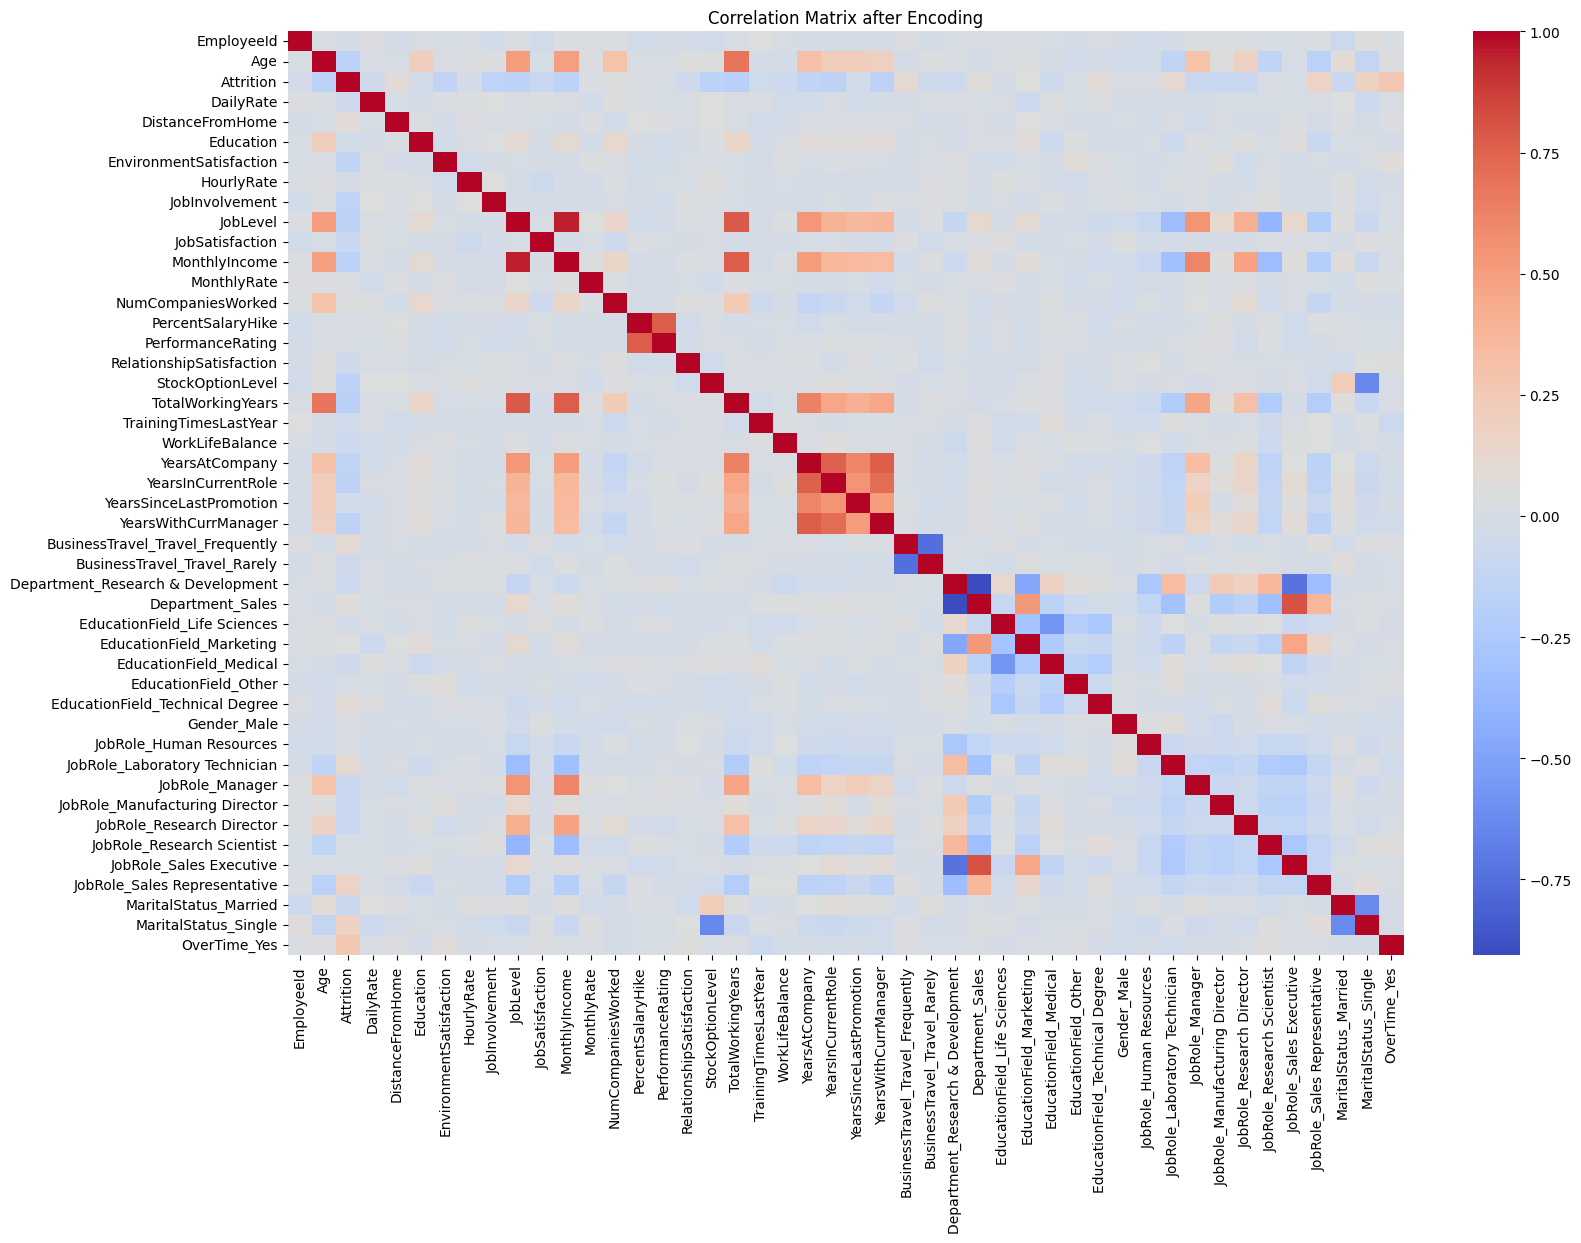

In [18]:
plt.figure(figsize=(18,12))
sns.heatmap(df_clean_encoded.corr(), annot=False, cmap="coolwarm")
plt.title("Correlation Matrix after Encoding")
plt.show()

In [19]:
correlations = df_clean_encoded.corr()['Attrition'].drop('Attrition').sort_values(ascending=False)
top_15_features = correlations.reindex(correlations.abs().sort_values(ascending=False).index).head(15)
print(top_15_features)

OverTime_Yes                        0.255856
MaritalStatus_Single                0.184303
TotalWorkingYears                  -0.177137
Age                                -0.172067
JobLevel                           -0.169201
JobRole_Sales Representative        0.168200
StockOptionLevel                   -0.164228
MonthlyIncome                      -0.163600
YearsInCurrentRole                 -0.158757
YearsWithCurrManager               -0.155962
JobInvolvement                     -0.150196
YearsAtCompany                     -0.135134
EnvironmentSatisfaction            -0.132848
JobRole_Laboratory Technician       0.113390
BusinessTravel_Travel_Frequently    0.104074
Name: Attrition, dtype: float64


C:\Users\Fathan Askar\AppData\Local\Temp\ipykernel_23912\503036273.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_15_features.values, y=top_15_features.index, palette="coolwarm")


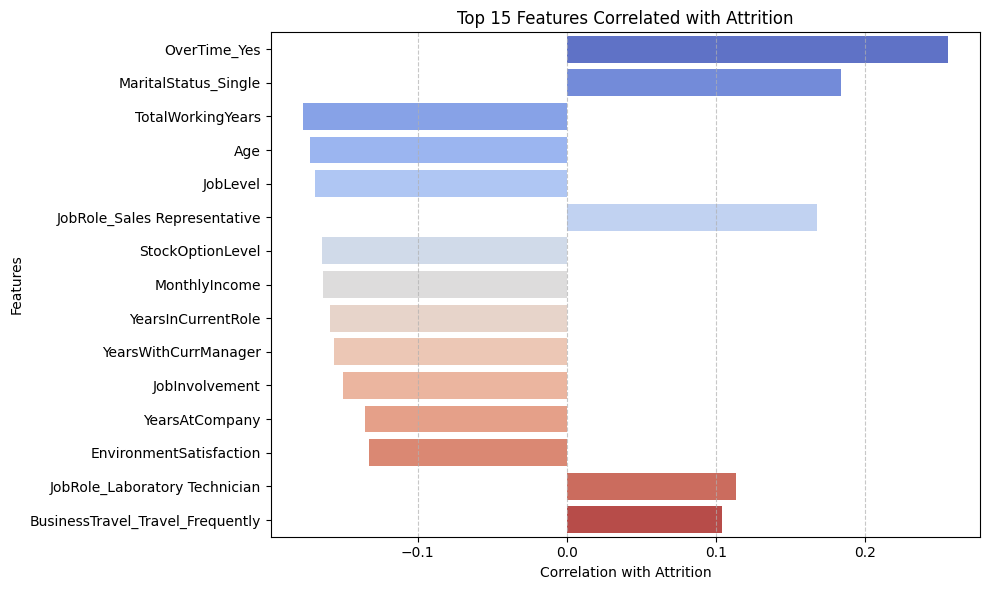

In [20]:
plt.figure(figsize=(10, 6))
sns.barplot(x=top_15_features.values, y=top_15_features.index, palette="coolwarm")
plt.title("Top 15 Features Correlated with Attrition")
plt.xlabel("Correlation with Attrition")
plt.ylabel("Features")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Exploratory Data Analyis (EDA)

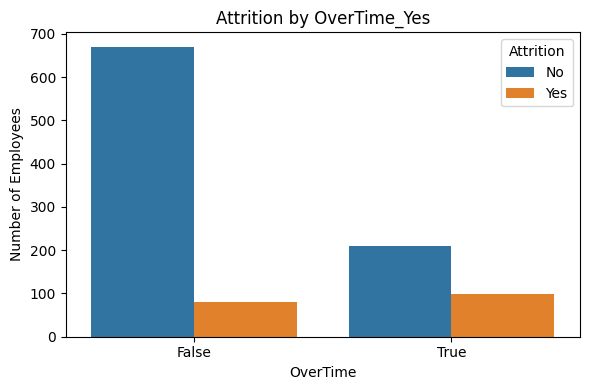

In [21]:
plt.figure(figsize=(6, 4))
sns.countplot(x="OverTime_Yes", hue="Attrition", data=df_clean_encoded)
plt.title("Attrition by OverTime_Yes")
plt.xlabel("OverTime")
plt.ylabel("Number of Employees")
plt.legend(title="Attrition", labels=["No", "Yes"])
plt.tight_layout()
plt.show()

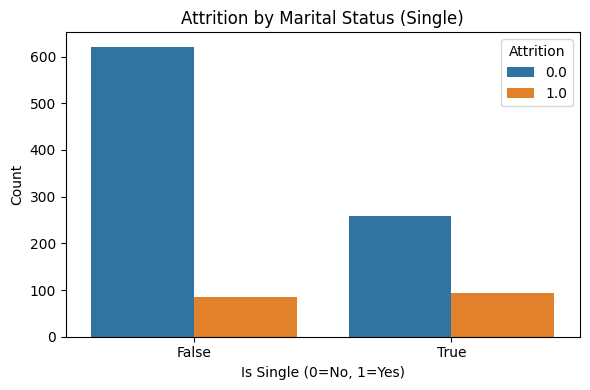

In [22]:
plt.figure(figsize=(6, 4))
sns.countplot(x="MaritalStatus_Single", hue="Attrition", data=df_clean_encoded)
plt.title("Attrition by Marital Status (Single)")
plt.xlabel("Is Single (0=No, 1=Yes)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

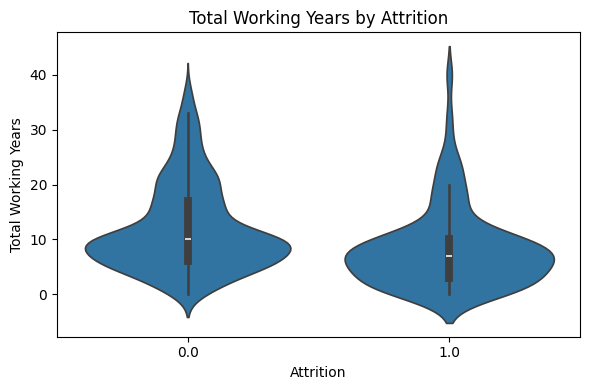

In [23]:
plt.figure(figsize=(6, 4))
sns.violinplot(x="Attrition", y="TotalWorkingYears", data=df_clean_encoded)
plt.title("Total Working Years by Attrition")
plt.xlabel("Attrition")
plt.ylabel("Total Working Years")
plt.tight_layout()
plt.show()

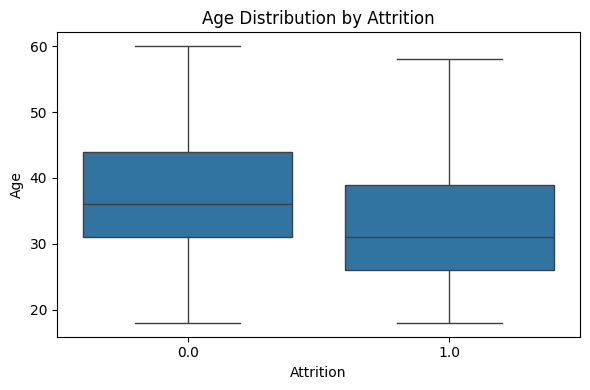

In [24]:
plt.figure(figsize=(6, 4))
sns.boxplot(x="Attrition", y="Age", data=df_clean_encoded)
plt.title("Age Distribution by Attrition")
plt.xlabel("Attrition")
plt.ylabel("Age")
plt.tight_layout()
plt.show()

C:\Users\Fathan Askar\AppData\Local\Temp\ipykernel_23912\2344841838.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x="JobLevel", y="Attrition", data=df_clean_encoded, ci=None)


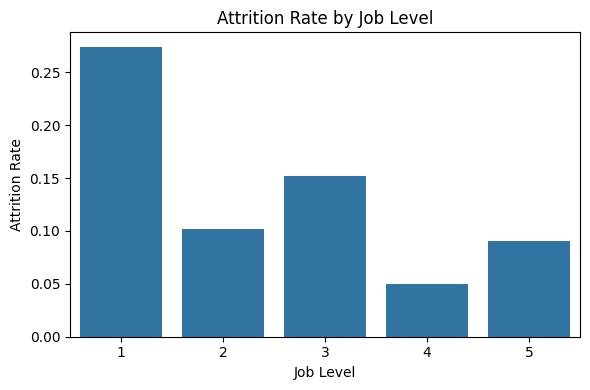

In [25]:
plt.figure(figsize=(6, 4))
sns.barplot(x="JobLevel", y="Attrition", data=df_clean_encoded, ci=None)
plt.title("Attrition Rate by Job Level")
plt.xlabel("Job Level")
plt.ylabel("Attrition Rate")
plt.tight_layout()
plt.show()

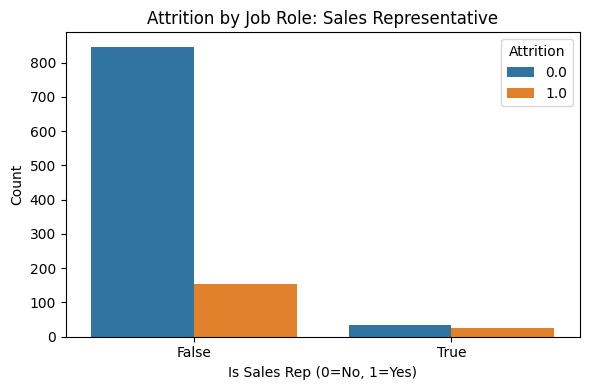

In [26]:
plt.figure(figsize=(6, 4))
sns.countplot(x="JobRole_Sales Representative", hue="Attrition", data=df_clean_encoded)
plt.title("Attrition by Job Role: Sales Representative")
plt.xlabel("Is Sales Rep (0=No, 1=Yes)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

C:\Users\Fathan Askar\AppData\Local\Temp\ipykernel_23912\4018602579.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x="StockOptionLevel", y="Attrition", data=df_clean_encoded, ci=None)


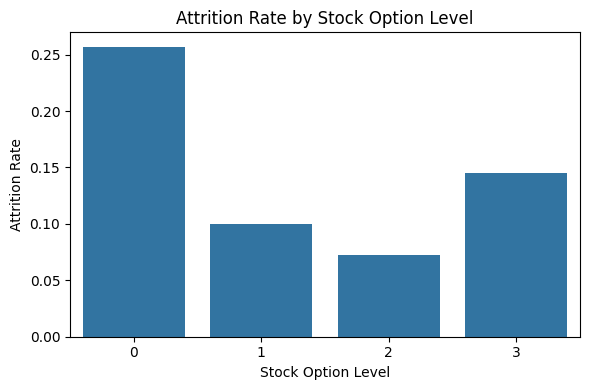

In [27]:
plt.figure(figsize=(6, 4))
sns.barplot(x="StockOptionLevel", y="Attrition", data=df_clean_encoded, ci=None)
plt.title("Attrition Rate by Stock Option Level")
plt.xlabel("Stock Option Level")
plt.ylabel("Attrition Rate")
plt.tight_layout()
plt.show()

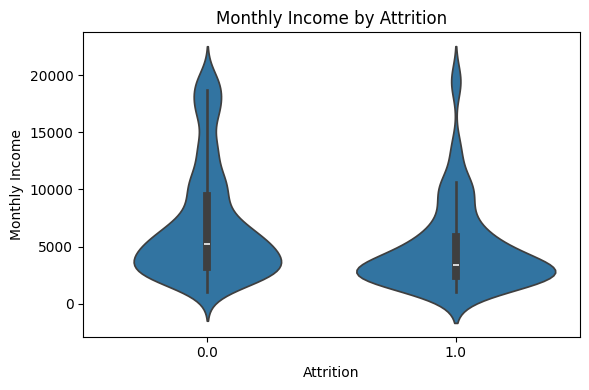

In [28]:
plt.figure(figsize=(6, 4))
sns.violinplot(x="Attrition", y="MonthlyIncome", data=df_clean_encoded)
plt.title("Monthly Income by Attrition")
plt.xlabel("Attrition")
plt.ylabel("Monthly Income")
plt.tight_layout()
plt.show()

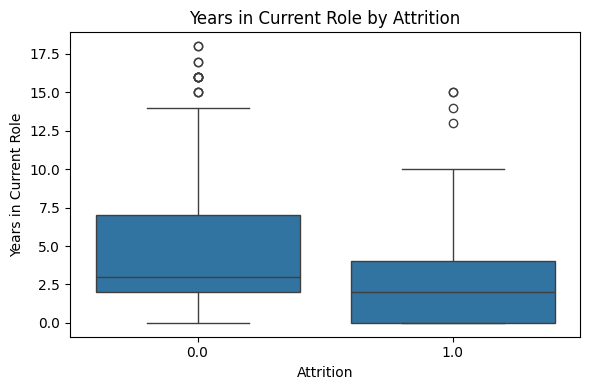

In [29]:
plt.figure(figsize=(6, 4))
sns.boxplot(x="Attrition", y="YearsInCurrentRole", data=df_clean_encoded)
plt.title("Years in Current Role by Attrition")
plt.xlabel("Attrition")
plt.ylabel("Years in Current Role")
plt.tight_layout()
plt.show()

C:\Users\Fathan Askar\AppData\Local\Temp\ipykernel_23912\4001822206.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x="YearsWithCurrManager", y="Attrition", data=df_clean_encoded, ci=None)


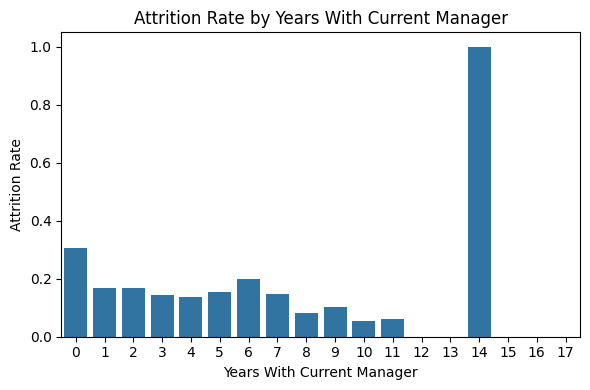

In [30]:
plt.figure(figsize=(6, 4))
sns.barplot(x="YearsWithCurrManager", y="Attrition", data=df_clean_encoded, ci=None)
plt.title("Attrition Rate by Years With Current Manager")
plt.xlabel("Years With Current Manager")
plt.ylabel("Attrition Rate")
plt.tight_layout()
plt.show()

C:\Users\Fathan Askar\AppData\Local\Temp\ipykernel_23912\50149552.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x="JobInvolvement", y="Attrition", data=df_clean_encoded, ci=None)


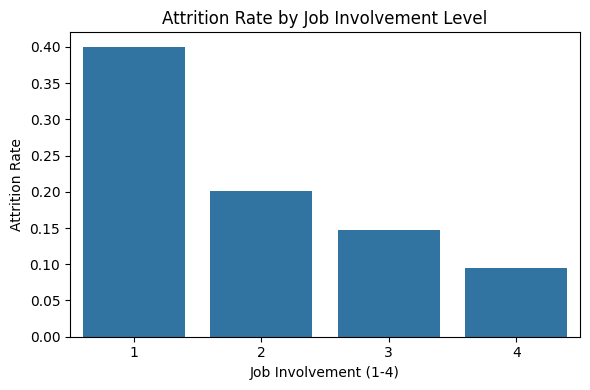

In [31]:
plt.figure(figsize=(6, 4))
sns.barplot(x="JobInvolvement", y="Attrition", data=df_clean_encoded, ci=None)
plt.title("Attrition Rate by Job Involvement Level")
plt.xlabel("Job Involvement (1-4)")
plt.ylabel("Attrition Rate")
plt.tight_layout()
plt.show()

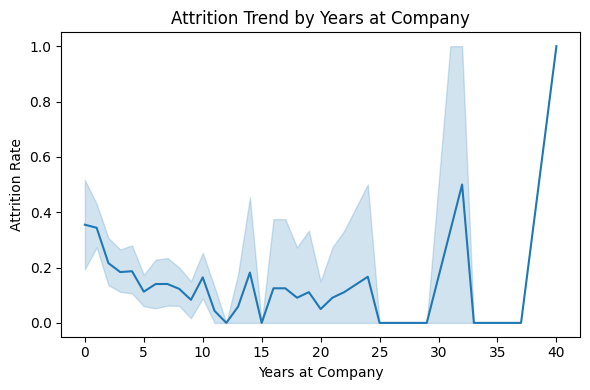

In [32]:
plt.figure(figsize=(6, 4))
sns.lineplot(x="YearsAtCompany", y="Attrition", data=df_clean_encoded)
plt.title("Attrition Trend by Years at Company")
plt.xlabel("Years at Company")
plt.ylabel("Attrition Rate")
plt.tight_layout()
plt.show()

C:\Users\Fathan Askar\AppData\Local\Temp\ipykernel_23912\1088724944.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x="EnvironmentSatisfaction", y="Attrition", data=df_clean_encoded, ci=None)


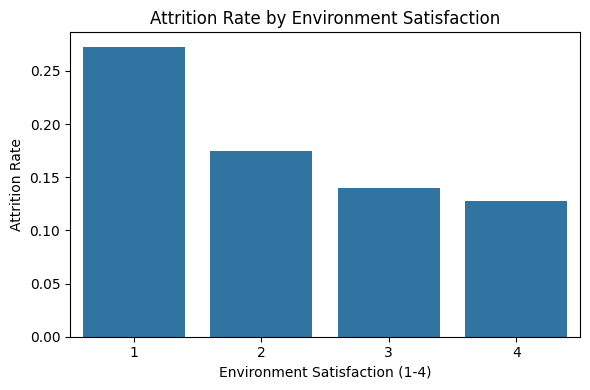

In [33]:
plt.figure(figsize=(6, 4))
sns.barplot(x="EnvironmentSatisfaction", y="Attrition", data=df_clean_encoded, ci=None)
plt.title("Attrition Rate by Environment Satisfaction")
plt.xlabel("Environment Satisfaction (1-4)")
plt.ylabel("Attrition Rate")
plt.tight_layout()
plt.show()

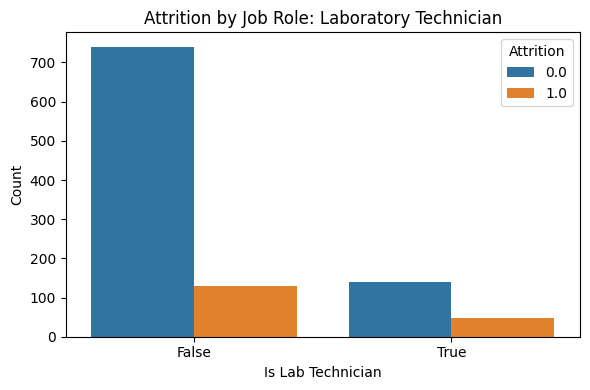

In [34]:
plt.figure(figsize=(6, 4))
sns.countplot(x="JobRole_Laboratory Technician", hue="Attrition", data=df_clean_encoded)
plt.title("Attrition by Job Role: Laboratory Technician")
plt.xlabel("Is Lab Technician")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

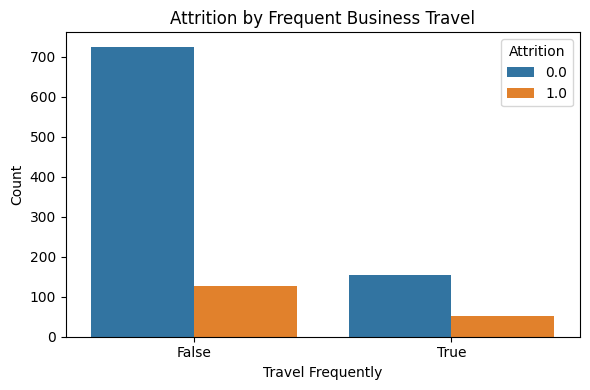

In [35]:
plt.figure(figsize=(6, 4))
sns.countplot(x="BusinessTravel_Travel_Frequently", hue="Attrition", data=df_clean_encoded)
plt.title("Attrition by Frequent Business Travel")
plt.xlabel("Travel Frequently")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

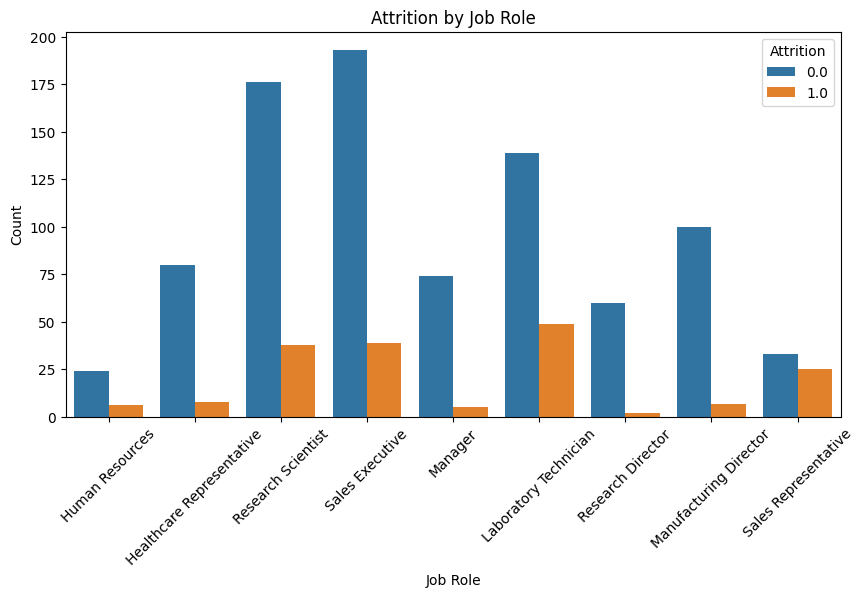

In [36]:
plt.figure(figsize=(10,5))
sns.countplot(data=df_clean, x='JobRole', hue='Attrition')
plt.title("Attrition by Job Role")
plt.xlabel("Job Role")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

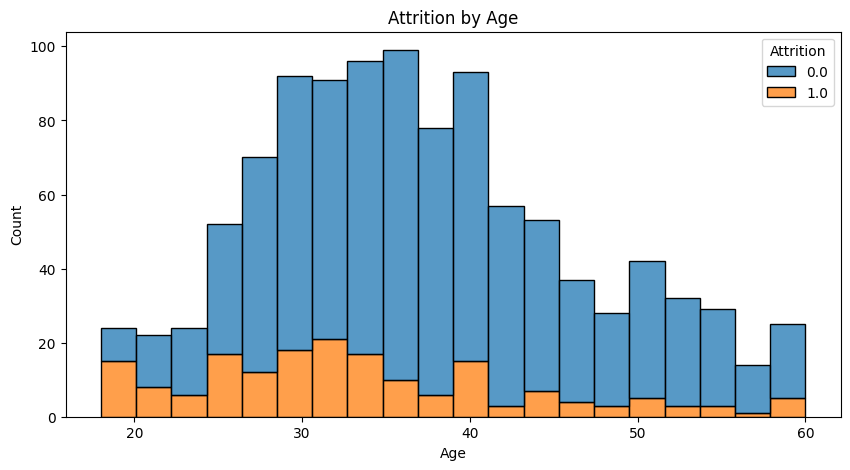

In [37]:
plt.figure(figsize=(10,5))
sns.histplot(data=df_clean_encoded, x='Age', hue='Attrition', multiple='stack', bins=20)
plt.title("Attrition by Age")
plt.show()

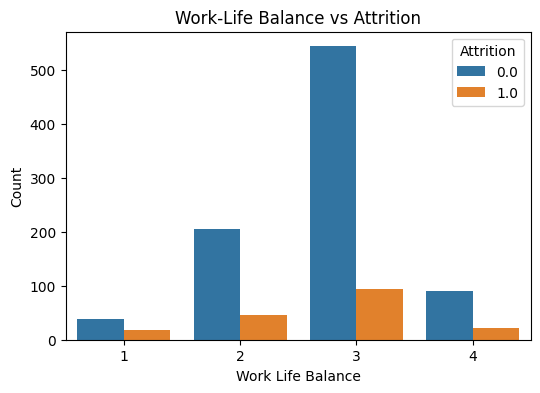

In [38]:
plt.figure(figsize=(6,4))
sns.countplot(data=df_clean_encoded, x='WorkLifeBalance', hue='Attrition')
plt.title("Work-Life Balance vs Attrition")
plt.xlabel("Work Life Balance")
plt.ylabel("Count")
plt.show()

C:\Users\Fathan Askar\AppData\Local\Temp\ipykernel_23912\309820492.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(["Stayed", "Left"])
C:\Users\Fathan Askar\AppData\Local\Temp\ipykernel_23912\309820492.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(["Stayed", "Left"])


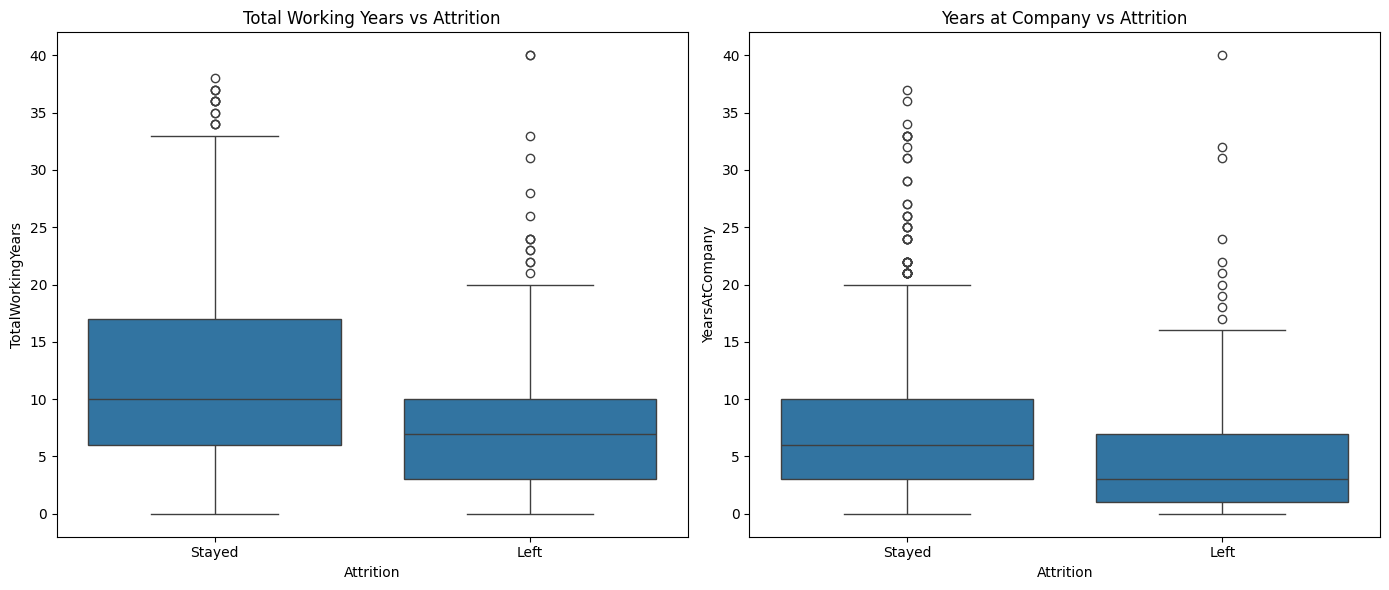

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))  # 1 row, 2 columns
sns.boxplot(data=df_clean_encoded, x='Attrition', y='TotalWorkingYears', ax=axes[0])
axes[0].set_title("Total Working Years vs Attrition")
axes[0].set_xticklabels(["Stayed", "Left"])
sns.boxplot(data=df_clean_encoded, x='Attrition', y='YearsAtCompany', ax=axes[1])
axes[1].set_title("Years at Company vs Attrition")
axes[1].set_xticklabels(["Stayed", "Left"])
plt.tight_layout()
plt.show()

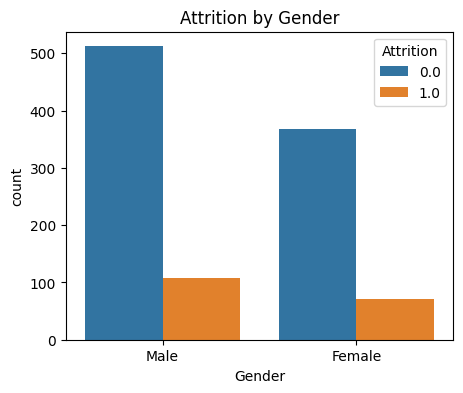

In [40]:
plt.figure(figsize=(5,4))
sns.countplot(data=df_clean, x='Gender', hue='Attrition')
plt.title("Attrition by Gender")
plt.show()

In [41]:
# #Code to make dataset from csv to db in order to put it in metabase
# import pandas as pd
# import sqlite3

# conn = sqlite3.connect("jaya_jaya_maju.db")
# df_clean.to_sql("employees", conn, if_exists="replace", index=False)
# conn.close()

## Modeling

In [42]:
#Prep dataset
df_clean = df_clean = df.dropna(subset=['Attrition']).copy()
df_clean['Attrition'] = df_clean['Attrition'].astype(int)
df_clean = df_clean.drop(columns=['EmployeeCount', 'StandardHours', 'Over18'])
df_clean = df_clean.dropna()

#Encode
categorical_cols = ['BusinessTravel', 'Department', 'EducationField', 
                    'Gender', 'JobRole', 'MaritalStatus', 'OverTime']
df_encoded = pd.get_dummies(df_clean, columns=categorical_cols, drop_first=True)

#Split Features and Target
X = df_encoded.drop('Attrition', axis=1)
y = df_encoded['Attrition']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42, stratify=y)

In [43]:
#Logistic Regression
log_model = LogisticRegression(max_iter=100000, class_weight='balanced')
log_model.fit(X_train, y_train)
y_pred_log = log_model.predict(X_test)
y_proba_log = log_model.predict_proba(X_test)[:, 1]

#Evaluate
print("Logistic Regression Results")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_log))
print("Classification Report:\n", classification_report(y_test, y_pred_log))
print("ROC AUC:", roc_auc_score(y_test, y_proba_log))

Logistic Regression Results
Confusion Matrix:
 [[62 26]
 [ 5 13]]
Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.70      0.80        88
           1       0.33      0.72      0.46        18

    accuracy                           0.71       106
   macro avg       0.63      0.71      0.63       106
weighted avg       0.82      0.71      0.74       106

ROC AUC: 0.8099747474747475


c:\Users\Fathan Askar\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF F,G EVALUATIONS EXCEEDS LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Fitting 3 folds for each of 108 candidates, totalling 324 fits
Tuned Random Forest Results
Best Parameters: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 10, 'min_samples_split': 10, 'n_estimators': 1000}
Confusion Matrix:
 [[79  9]
 [ 7 11]]
Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.90      0.91        88
           1       0.55      0.61      0.58        18

    accuracy                           0.85       106
   macro avg       0.73      0.75      0.74       106
weighted avg       0.86      0.85      0.85       106

ROC AUC: 0.8068181818181819


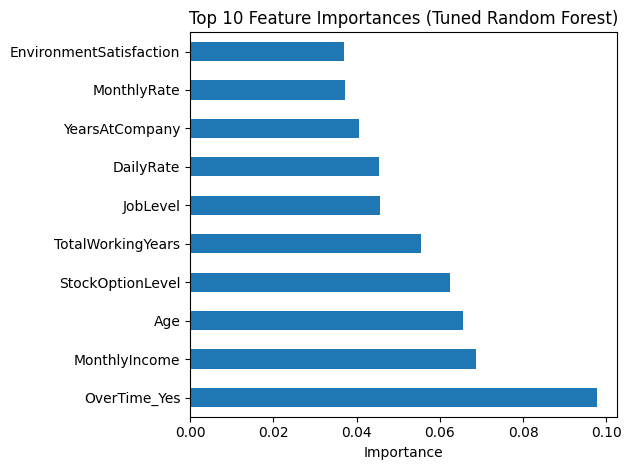

In [44]:
#RandomForest
param_grid = {
    'n_estimators': [1000, 2000],
    'max_depth': [5, 10, 20],
    'min_samples_split': [10, 20, 30],
    'min_samples_leaf': [10, 20, 30],
    'max_features': ['sqrt', 'log2'],
}
#Gridsearch to find the best parameters
grid_search_rf = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42, class_weight='balanced'),
    param_grid=param_grid,
    cv=3,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)
grid_search_rf.fit(X_train, y_train)
best_rf = grid_search_rf.best_estimator_

#Predict
y_pred_rf = best_rf.predict(X_test)
y_proba_rf = best_rf.predict_proba(X_test)[:, 1]

#Evaluation
print("Tuned Random Forest Results")
print("Best Parameters:", grid_search_rf.best_params_)
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("Classification Report:\n", classification_report(y_test, y_pred_rf))
print("ROC AUC:", roc_auc_score(y_test, y_proba_rf))

#Feature importance
importances = pd.Series(best_rf.feature_importances_, index=X.columns)
importances.nlargest(10).plot(kind='barh')
plt.title("Top 10 Feature Importances (Tuned Random Forest)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()


Fitting 3 folds for each of 36 candidates, totalling 108 fits


c:\Users\Fathan Askar\AppData\Local\Programs\Python\Python310\lib\site-packages\xgboost\core.py:158: UserWarning: [11:16:33] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Best XGBoost Parameters: {'learning_rate': 0.005, 'max_depth': 5, 'n_estimators': 2000, 'subsample': 0.1}

XGBoost Results
Confusion Matrix:
 [[86  2]
 [11  7]]
Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.98      0.93        88
           1       0.78      0.39      0.52        18

    accuracy                           0.88       106
   macro avg       0.83      0.68      0.72       106
weighted avg       0.87      0.88      0.86       106

ROC AUC: 0.8573232323232324


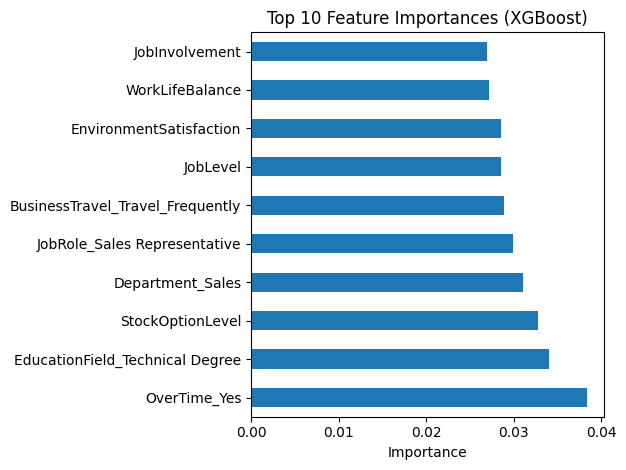

In [45]:
#XGBoost
xgb = XGBClassifier(
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)
param_grid = {
    'n_estimators': [1000, 2000],
    'max_depth': [5, 10, 20],
    'learning_rate': [0.005, 0.01],
    'subsample': [0.1, 0.5, 0.7]
}
#Gridsearch to find the best parameters
grid_search = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=3,
    verbose=1,
    n_jobs=-1
)
grid_search.fit(X_train, y_train)
best_xgb = grid_search.best_estimator_

#Predict
y_pred_xgb = best_xgb.predict(X_test)
y_proba_xgb = best_xgb.predict_proba(X_test)[:, 1]

# valuation
print("Best XGBoost Parameters:", grid_search.best_params_)
print("\nXGBoost Results")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_xgb))
print("Classification Report:\n", classification_report(y_test, y_pred_xgb))
print("ROC AUC:", roc_auc_score(y_test, y_proba_xgb))

#Feature Importance
importances = pd.Series(best_xgb.feature_importances_, index=X.columns)
importances.nlargest(10).plot(kind='barh')
plt.title("Top 10 Feature Importances (XGBoost)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

In [ ]:
#Save the XGBoost model
joblib.dump(best_xgb, 'xgboost_model.pkl')

['xgboost_model.pkl']